# Phase 2: Pembersihan & Imputasi Data (Cleaning & Imputation)

Notebook ini berfokus pada penanganan missing values AOD akibat tutupan awan (menggunakan interpolasi spasial atau temporal) serta penyaringan anomali data stasiun.

## EDA

### PM2.5

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Atur tema visualisasi agar terlihat premium dan bersih
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# Load data PM2.5
pm25_path = os.path.join('data', 'pm25', 'combined_pm25.csv')
df_pm25 = pd.read_csv(pm25_path)
df_pm25['waktu'] = pd.to_datetime(df_pm25['waktu'])

# Tambahkan ekstraksi waktu dasar untuk analisis visual
df_pm25['jam'] = df_pm25['waktu'].dt.hour
df_pm25['bulan'] = df_pm25['waktu'].dt.month
df_pm25['tahun'] = df_pm25['waktu'].dt.year
df_pm25['hari_nama'] = df_pm25['waktu'].dt.day_name()

# Urutan hari Senin - Minggu
order_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_pm25['hari_nama'] = pd.Categorical(df_pm25['hari_nama'], categories=order_hari, ordered=True)

print(df_pm25.info())
print("\nStatistik Deskriptif PM2.5 per Stasiun:")
print(df_pm25.groupby('stasiun')['PM2.5'].describe())

Matplotlib is building the font cache; this may take a moment.


<class 'pandas.DataFrame'>
RangeIndex: 131640 entries, 0 to 131639
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   waktu      131640 non-null  datetime64[us]
 1   PM2.5      131640 non-null  float64       
 2   stasiun    131640 non-null  str           
 3   latitude   131640 non-null  float64       
 4   longitude  131640 non-null  float64       
 5   jam        131640 non-null  int32         
 6   bulan      131640 non-null  int32         
 7   tahun      131640 non-null  int32         
 8   hari_nama  131640 non-null  category      
dtypes: category(1), datetime64[us](1), float64(3), int32(3), str(1)
memory usage: 6.7 MB
None

Statistik Deskriptif PM2.5 per Stasiun:
                       count       mean        std  min   25%   50%   75%  \
stasiun                                                                     
Jagakarsa            26328.0  66.539881  35.040850  3.4  41.0  61.5  86.1   
Jatine

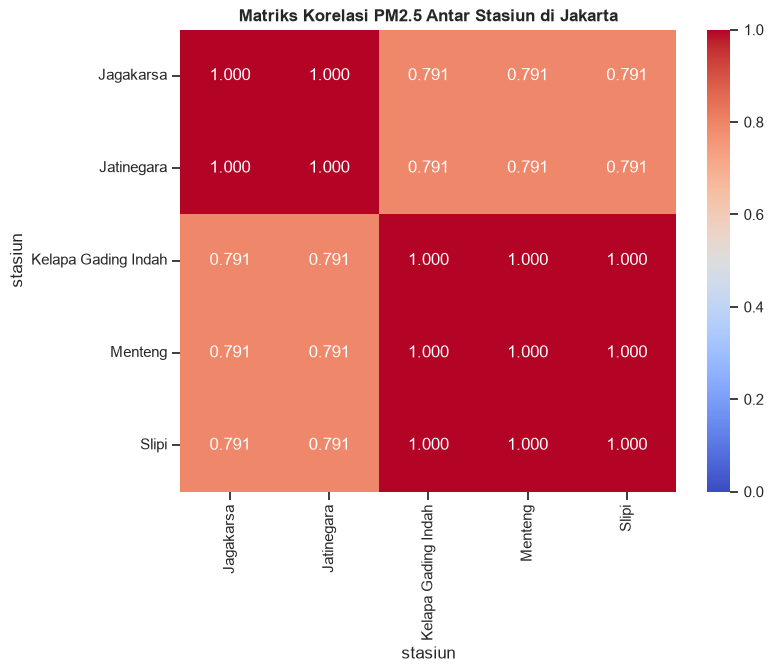

In [3]:
# Pivot data untuk membuat kolom PM2.5 per stasiun
df_pivot = df_pm25.pivot(index='waktu', columns='stasiun', values='PM2.5')

# Hitung matriks korelasi Pearson
corr_matrix = df_pivot.corr()

# Tampilkan Heatmap Korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".3f")
plt.title('Matriks Korelasi PM2.5 Antar Stasiun di Jakarta', fontsize=12, fontweight='bold')
plt.show()

### cuaca

Info Dataset Cuaca:
<class 'pandas.DataFrame'>
RangeIndex: 131640 entries, 0 to 131639
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   waktu                 131640 non-null  datetime64[us]
 1   temperature_2m        131640 non-null  float64       
 2   apparent_temperature  131640 non-null  float64       
 3   relative_humidity_2m  131640 non-null  int64         
 4   dew_point_2m          131640 non-null  float64       
 5   precipitation         131640 non-null  float64       
 6   rain                  131640 non-null  float64       
 7   surface_pressure      131640 non-null  float64       
 8   cloud_cover_total     131640 non-null  int64         
 9   wind_speed_10m        131640 non-null  float64       
 10  wind_direction_10m    131640 non-null  int64         
 11  stasiun               131640 non-null  str           
 12  latitude              131640 non-null  float64   

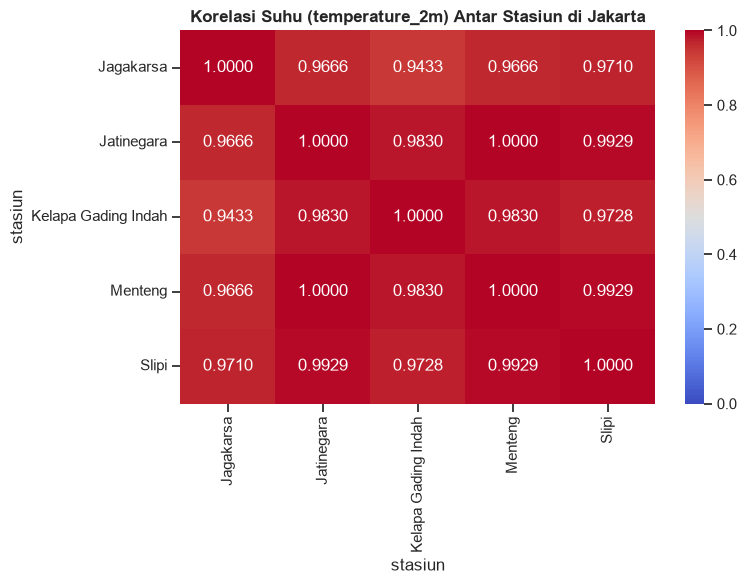


RATA-RATA PARAMETER CUACA UTAMA PER STASIUN
                     temperature_2m  relative_humidity_2m  surface_pressure  \
stasiun                                                                       
Jagakarsa                 26.730986             80.738605       1003.042871   
Jatinegara                27.350817             79.634875       1007.322998   
Kelapa Gading Indah       27.357069             79.580371       1008.919682   
Menteng                   27.350817             79.634875       1008.234340   
Slipi                     27.293805             79.977400       1008.704417   

                     wind_speed_10m  
stasiun                              
Jagakarsa                  6.371414  
Jatinegara                 6.099138  
Kelapa Gading Indah        7.446149  
Menteng                    6.099138  
Slipi                      5.935517  

PERBANDINGAN DATA CUACA MENTENG VS SLIPI (3 Jam Pertama)

[SLIPI]
                waktu  temperature_2m  wind_speed_10m
0 2023-01-01 0

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['figure.dpi'] = 100

# ==========================================
# 1. LOAD DATA CUACA GABUNGAN
# ==========================================
weather_path = os.path.join('data', 'cuaca', 'combined_weather.csv')
if not os.path.exists(weather_path):
    raise FileNotFoundError(f"File {weather_path} tidak ditemukan! Pastikan cell 1.3 sudah dijalankan.")

df_weather = pd.read_csv(weather_path)
df_weather['waktu'] = pd.to_datetime(df_weather['waktu'])

print("Info Dataset Cuaca:")
print(df_weather.info())

# ==========================================
# 2. UJI DUPLIKASI SPASIAL (KORELASI SUHU)
# ==========================================
print("\n" + "="*60)
print("UJI DUPLIKASI: MATRIKS KORELASI SUHU (temperature_2m)")
print("="*60)

# Pivot data suhu udara untuk menyejajarkan waktu antar stasiun
df_temp_pivot = df_weather.pivot(index='waktu', columns='stasiun', values='temperature_2m')

# Hitung korelasi Pearson
temp_corr = df_temp_pivot.corr()

# Tampilkan Heatmap Korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(temp_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".4f")
plt.title('Korelasi Suhu (temperature_2m) Antar Stasiun di Jakarta', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 3. CEK NILAI PARAMETER CUACA PER STASIUN
# ==========================================
print("\n" + "="*60)
print("RATA-RATA PARAMETER CUACA UTAMA PER STASIUN")
print("="*60)
weather_vars = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
mean_weather = df_weather.groupby('stasiun')[weather_vars].mean()
print(mean_weather)

# Tampilkan contoh 3 baris data pertama untuk Slipi dan Menteng secara berdampingan untuk verifikasi
print("\n" + "="*60)
print("PERBANDINGAN DATA CUACA MENTENG VS SLIPI (3 Jam Pertama)")
print("="*60)
print("\n[SLIPI]")
print(df_weather[df_weather['stasiun'] == 'Slipi'][['waktu', 'temperature_2m', 'wind_speed_10m']].head(3))
print("\n[MENTENG]")
print(df_weather[df_weather['stasiun'] == 'Menteng'][['waktu', 'temperature_2m', 'wind_speed_10m']].head(3))

### aod

ANALISIS KEKOSONGAN DATA (NaN) AOD HIMAWARI
Total Baris Data    : 54850
Piksel Valid (Cerah): 4766 (8.69%)
Piksel Kosong (NaN) : 50084 (91.31%) -> Akibat awan + malam hari

Persentase Data AOD Kosong per Stasiun:
            stasiun  persentase_NaN
          Jagakarsa       92.889699
         Jatinegara       92.142206
Kelapa Gading Indah       87.702826
            Menteng       91.230629
              Slipi       92.588879


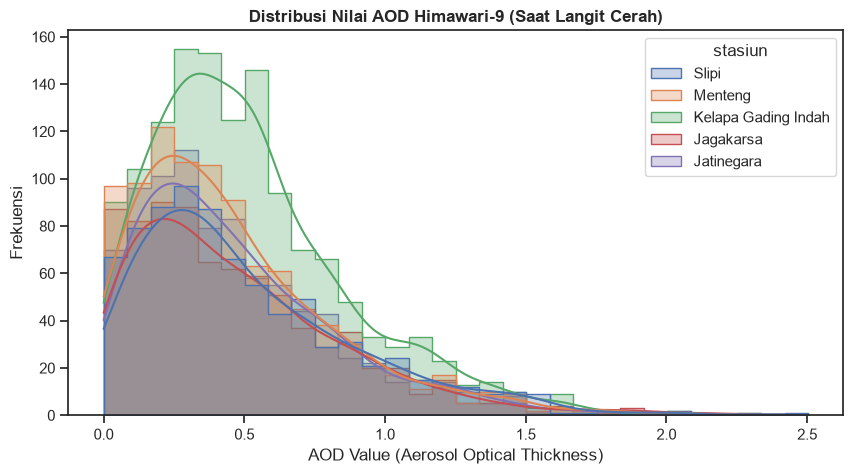


KORELASI FISIK ANTARA AOD SATELIT & PM2.5 DARAT (JAM CERAH)
Koefisien Korelasi Pearson (AOD vs PM2.5): 0.2779


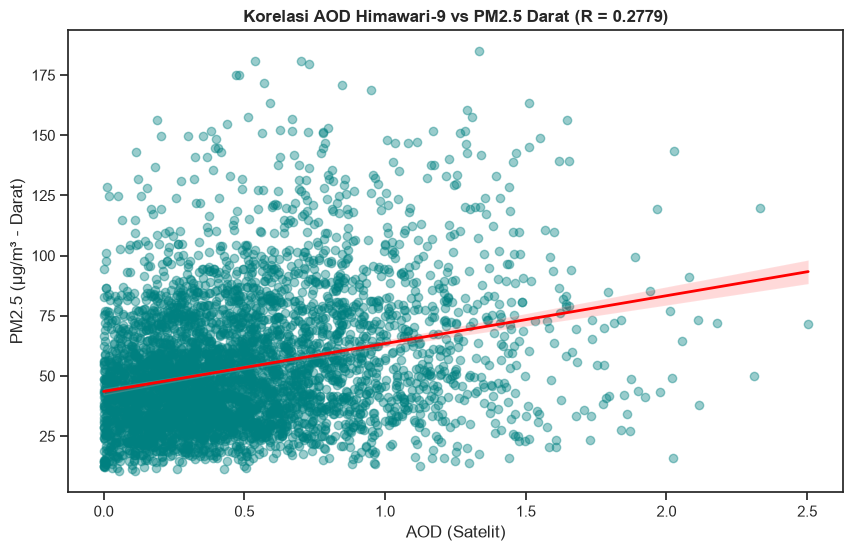

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# ==========================================
# 1. LOAD DATA AOD & PM2.5
# ==========================================
aod_path = os.path.join('data', 'aod', 'combined_aod.csv')
pm25_path = os.path.join('data', 'pm25', 'combined_pm25.csv')

df_aod = pd.read_csv(aod_path)
df_pm25 = pd.read_csv(pm25_path)

df_aod['waktu'] = pd.to_datetime(df_aod['waktu'])
df_pm25['waktu'] = pd.to_datetime(df_pm25['waktu'])

# ==========================================
# 2. ANALISIS MISSING DATA (TUTUPAN AWAN & MALAM)
# ==========================================
print("="*60)
print("ANALISIS KEKOSONGAN DATA (NaN) AOD HIMAWARI")
print("="*60)
total_rows = len(df_aod)
nan_count = df_aod['AOD'].isnull().sum()
valid_count = total_rows - nan_count

print(f"Total Baris Data    : {total_rows}")
print(f"Piksel Valid (Cerah): {valid_count} ({valid_count/total_rows*100:.2f}%)")
print(f"Piksel Kosong (NaN) : {nan_count} ({nan_count/total_rows*100:.2f}%) -> Akibat awan + malam hari")

# Cek persentase NaN per stasiun
nan_per_station = df_aod.groupby('stasiun')['AOD'].apply(lambda x: x.isnull().sum() / len(x) * 100).reset_index()
nan_per_station.columns = ['stasiun', 'persentase_NaN']
print("\nPersentase Data AOD Kosong per Stasiun:")
print(nan_per_station.to_string(index=False))

# ==========================================
# 3. DISTRIBUSI NILAI AOD SAAT CERAH
# ==========================================
# Filter hanya data AOD yang tidak NaN
df_aod_valid = df_aod.dropna(subset=['AOD'])

plt.figure(figsize=(10, 5))
sns.histplot(data=df_aod_valid, x='AOD', hue='stasiun', kde=True, bins=30, element='step', alpha=0.3)
plt.title('Distribusi Nilai AOD Himawari-9 (Saat Langit Cerah)', fontsize=12, fontweight='bold')
plt.xlabel('AOD Value (Aerosol Optical Thickness)')
plt.ylabel('Frekuensi')
plt.show()

# ==========================================
# 4. KORELASI SPASIAL: AOD VS PM2.5 (PADA JAM CERAH)
# ==========================================
# Gabungkan sementara data PM2.5 dan AOD berdasarkan waktu & stasiun
df_temp_merge = pd.merge(df_pm25, df_aod_valid, on=['waktu', 'stasiun'], how='inner')

print("\n" + "="*60)
print("KORELASI FISIK ANTARA AOD SATELIT & PM2.5 DARAT (JAM CERAH)")
print("="*60)
correlation = df_temp_merge['AOD'].corr(df_temp_merge['PM2.5'])
print(f"Koefisien Korelasi Pearson (AOD vs PM2.5): {correlation:.4f}")

# Plot Scatter dengan Garis Regresi
plt.figure(figsize=(10, 6))
sns.regplot(data=df_temp_merge, x='AOD', y='PM2.5',
            scatter_kws={'alpha':0.4, 'color':'teal'},
            line_kws={'color':'red', 'linewidth':2})
plt.title(f'Korelasi AOD Himawari-9 vs PM2.5 Darat (R = {correlation:.4f})', fontsize=12, fontweight='bold')
plt.xlabel('AOD (Satelit)')
plt.ylabel('PM2.5 (µg/m³ - Darat)')
plt.show()

# Phase 2: Pembersihan & Imputasi Data (Cleaning & Imputation)

Notebook ini berfokus pada penggabungan tiga dataset utama (PM2.5, Cuaca, dan AOD), pengisian nilai yang hilang (*missing values*), serta pembersihan data anomali sebelum masuk ke tahap rekayasa fitur.

In [6]:
import os
import pandas as pd
import numpy as np

# Path ke file data
pm25_path = os.path.join('data', 'pm25', 'combined_pm25.csv')
weather_path = os.path.join('data', 'cuaca', 'combined_weather.csv')
aod_path = os.path.join('data', 'aod', 'combined_aod.csv')

# Load data
df_pm25 = pd.read_csv(pm25_path)
df_weather = pd.read_csv(weather_path)
df_aod = pd.read_csv(aod_path)

# Format kolom waktu menjadi datetime
df_pm25['waktu'] = pd.to_datetime(df_pm25['waktu'])
df_weather['waktu'] = pd.to_datetime(df_weather['waktu'])
df_aod['waktu'] = pd.to_datetime(df_aod['waktu'])

print("--- UKURAN DATA AWAL ---")
print(f"Data PM2.5 : {df_pm25.shape}")
print(f"Data Cuaca : {df_weather.shape}")
print(f"Data AOD   : {df_aod.shape}")

# 1. Gabungkan PM2.5 dengan Cuaca (keduanya memiliki data 24 jam penuh)
df_merged = pd.merge(df_pm25, df_weather, on=['waktu', 'stasiun'], how='inner')
print(f"\nUkuran setelah merge PM2.5 & Cuaca: {df_merged.shape}")

# 2. Lakukan Left Join dengan data AOD satelit agar data malam hari tidak hilang
df_final = pd.merge(df_merged, df_aod, on=['waktu', 'stasiun'], how='left')
print(f"Ukuran akhir setelah Left Join AOD: {df_final.shape}")

# Tampilkan ringkasan data kosong (NaN) sebelum imputasi
print("\nJumlah Data Kosong (NaN) per Kolom:")
print(df_final.isnull().sum())

--- UKURAN DATA AWAL ---
Data PM2.5 : (131640, 5)
Data Cuaca : (131640, 14)
Data AOD   : (54850, 3)

Ukuran setelah merge PM2.5 & Cuaca: (131640, 17)
Ukuran akhir setelah Left Join AOD: (131640, 18)

Jumlah Data Kosong (NaN) per Kolom:
waktu                        0
PM2.5                        0
stasiun                      0
latitude_x                   0
longitude_x                  0
temperature_2m               0
apparent_temperature         0
relative_humidity_2m         0
dew_point_2m                 0
precipitation                0
rain                         0
surface_pressure             0
cloud_cover_total            0
wind_speed_10m               0
wind_direction_10m           0
latitude_y                   0
longitude_y                  0
AOD                     126874
dtype: int64


### Penanganan Missing Values (Imputasi)

In [ ]:
# Urutkan data berdasarkan stasiun dan waktu untuk memastikan interpolasi berjalan runtut
df_final = df_final.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)

# 1. Interpolasi linier waktu untuk kolom cuaca & PM2.5 (batas maksimal 3 jam beruntun)
cols_to_interpolate = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'wind_speed_10m', 'wind_direction_10m', 'PM2.5'
]

print("Melakukan interpolasi kolom cuaca dan PM2.5...")
for col in cols_to_interpolate:
    if col in df_final.columns:
        df_final[col] = df_final.groupby('stasiun')[col].transform(lambda x: x.interpolate(method='linear', limit=3))

# 2. Imputasi AOD dengan Sentinel Value (-999.0)
print("Mengimputasi nilai kosong AOD dengan Sentinel Value (-999.0)...")
df_final['AOD'] = df_final['AOD'].fillna(-999.0)

# Cek kembali kekosongan data
print("\nJumlah Data Kosong (NaN) setelah Imputasi:")
print(df_final.isnull().sum())

Melakukan interpolasi kolom cuaca dan PM2.5...
Mengimputasi nilai kosong AOD dengan Sentinel Value (-999.0)...

Jumlah Data Kosong (NaN) setelah Imputasi:
waktu                   0
PM2.5                   0
stasiun                 0
latitude_x              0
longitude_x             0
temperature_2m          0
apparent_temperature    0
relative_humidity_2m    0
dew_point_2m            0
precipitation           0
rain                    0
surface_pressure        0
cloud_cover_total       0
wind_speed_10m          0
wind_direction_10m      0
latitude_y              0
longitude_y             0
AOD                     0
dtype: int64


### Pembersihan Anomali & Penyimpanan Dataset Master

In [8]:
# 1. Cek jika ada nilai PM2.5 negatif (anomali sensor)
negative_pm25_count = (df_final['PM2.5'] < 0).sum()
print(f"Jumlah baris data PM2.5 negatif (anomali): {negative_pm25_count}")

# Hapus baris dengan PM2.5 negatif jika ada
if negative_pm25_count > 0:
    df_final = df_final[df_final['PM2.5'] >= 0].reset_index(drop=True)
    print("-> Baris data PM2.5 negatif berhasil dihapus.")

# 2. Tampilkan deskripsi statistik akhir untuk verifikasi data
print("\nStatistik Deskriptif Akhir Dataset:")
print(df_final.describe())

# 3. Simpan dataset master bersih
clean_output_path = os.path.join('data', 'clean_imputed_data.csv')
df_final.to_csv(clean_output_path, index=False)

print(f"\n✓ SELESAI! Dataset master bersih disimpan di: {clean_output_path}")
print(f"Total baris data siap pakai: {len(df_final)}")

Jumlah baris data PM2.5 negatif (anomali): 0

Statistik Deskriptif Akhir Dataset:
                     waktu          PM2.5     latitude_x    longitude_x  \
count               131640  131640.000000  131640.000000  131640.000000   
mean   2024-07-02 11:30:00      57.485773      -6.219997     106.840010   
min    2023-01-01 00:00:00       3.400000      -6.299995     106.800020   
25%    2023-10-02 05:45:00      32.900000      -6.199997     106.800020   
50%    2024-07-02 11:30:00      52.200000      -6.199997     106.800020   
75%    2025-04-02 17:15:00      75.700000      -6.199997     106.899994   
max    2026-01-01 23:00:00     238.400000      -6.199997     106.899994   
std                    NaN      31.978475       0.040000       0.048977   

       temperature_2m  apparent_temperature  relative_humidity_2m  \
count   131640.000000         131640.000000         131640.000000   
mean        27.216699             32.102977             79.913225   
min         19.200000             2

### Sinkronisasi data lat, lon

In [9]:
# Tentukan koordinat stasiun asli untuk pemodelan spasial
station_coords = {
    'Slipi': {'lat': -6.1950, 'lon': 106.8025},
    'Menteng': {'lat': -6.1994, 'lon': 106.8392},
    'Jagakarsa': {'lat': -6.3341, 'lon': 106.8214},
    'Jatinegara': {'lat': -6.2322, 'lon': 106.8811},
    'Kelapa Gading Indah': {'lat': -6.1673, 'lon': 106.9052}
}

# 1. Map stasiun ke koordinat aslinya
df_final['latitude'] = df_final['stasiun'].map(lambda x: station_coords[x]['lat'])
df_final['longitude'] = df_final['stasiun'].map(lambda x: station_coords[x]['lon'])

# 2. Hapus kolom koordinat duplikat hasil merge (_x dan _y)
cols_to_drop = ['latitude_x', 'longitude_x', 'latitude_y', 'longitude_y']
df_final = df_final.drop(columns=[col for col in cols_to_drop if col in df_final.columns])

# 3. Tampilkan info kolom terbaru
print("Kolom terbaru setelah dirapikan:")
print(df_final.columns.tolist())
print(df_final[['stasiun', 'latitude', 'longitude']].drop_duplicates())

# 4. Simpan kembali dataset master bersih ter-update
df_final.to_csv(clean_output_path, index=False)
print(f"\n✓ SELESAI SEMPURNA! Dataset master bersih ter-update disimpan di: {clean_output_path}")

Kolom terbaru setelah dirapikan:
['waktu', 'PM2.5', 'stasiun', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'rain', 'surface_pressure', 'cloud_cover_total', 'wind_speed_10m', 'wind_direction_10m', 'AOD', 'latitude', 'longitude']
                    stasiun  latitude  longitude
0                 Jagakarsa   -6.3341   106.8214
26328            Jatinegara   -6.2322   106.8811
52656   Kelapa Gading Indah   -6.1673   106.9052
78984               Menteng   -6.1994   106.8392
105312                Slipi   -6.1950   106.8025

✓ SELESAI SEMPURNA! Dataset master bersih ter-update disimpan di: data\clean_imputed_data.csv
